In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_excel("data/Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

FileNotFoundError: [Errno 2] No such file or directory: 'data/Online Retail.xlsx'

In [4]:
import os
print(os.getcwd())

C:\Users\DELL\Desktop\OIBSIP\DataAnalytics-L1-CustomerSegmentation\data


In [5]:
pd.read_excel("data/Online Retail.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'data/Online Retail.xlsx'

In [ ]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

KeyboardInterrupt: 

In [ ]:
import pandas as pd

excel_file = "Online Retail.xlsx"

df = pd.read_excel(excel_file, engine="openpyxl")

df.to_csv("Online Retail.csv", index=False)

print("Excel converted to CSV successfully!")

KeyboardInterrupt: 

In [1]:
import pandas as pd

df = pd.read_csv("Online Retail.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

FileNotFoundError: [Errno 2] No such file or directory: 'Online Retail.csv'

In [2]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
C:\Users\DELL\Desktop\OIBSIP\DataAnalytics-L1-CustomerSegmentation\data

Files in this folder:
['.ipynb_checkpoints', 'Customer_Segmentation.ipynb', 'Online Retail.csv.xlsx']


In [ ]:
import pandas as pd

df = pd.read_excel("Online Retail.csv.xlsx", engine="openpyxl")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

KeyboardInterrupt: 

In [1]:

import os

os.rename("Online Retail.csv.xlsx", "Online Retail.xlsx")

print("File renamed successfully!")

File renamed successfully!


In [2]:
print(os.listdir())

['.ipynb_checkpoints', 'Customer_Segmentation.ipynb', 'Online Retail.xlsx']


In [3]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Customer_Segmentation.ipynb', 'Online Retail.xlsx']


In [ ]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx", engine="openpyxl")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

KeyboardInterrupt: 

In [1]:
import pandas as pd

df = pd.read_csv("Online Retail.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 541909
Columns: 8


In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [6]:
print("Original rows:", len(df))

df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Original rows: 541909
Rows after removing duplicates: 536641


In [7]:
df = df.dropna(subset=['CustomerID'])

print("Rows after removing missing CustomerID:", len(df))

Rows after removing missing CustomerID: 401604


In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Rows after removing cancelled invoices:", len(df))

Rows after removing cancelled invoices: 392732


In [9]:
df = df[df['Quantity'] > 0]

print("Rows after removing invalid quantities:", len(df))

Rows after removing invalid quantities: 392732


In [10]:
df = df[df['UnitPrice'] > 0]

print("Rows after removing invalid prices:", len(df))

Rows after removing invalid prices: 392692


In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("InvoiceDate converted successfully!")
print(df['InvoiceDate'].dtype)

InvoiceDate converted successfully!
datetime64[us]


In [12]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [13]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Final dataset shape: (392692, 9)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


In [14]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [15]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [16]:
print("Number of customers:", len(rfm))

Number of customers: 4338


In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [18]:
print("Missing values in RFM:")
print(rfm.isnull().sum())

Missing values in RFM:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [19]:
rfm['Customer_Lifetime_Value'] = rfm['Monetary']

rfm[['Recency', 'Frequency', 'Monetary',
     'Customer_Lifetime_Value']].head()

,Recency,Frequency,Monetary,Customer_Lifetime_Value
CustomerID,,,,
12346.0,326,1,77183.60,77183.60
12347.0,2,7,4310.00,4310.00
12348.0,75,4,1797.24,1797.24
12349.0,19,1,1757.55,1757.55
12350.0,310,1,334.40,334.40


In [20]:
print("Average Purchase Value:",
      df['TotalAmount'].mean())

print("Average Purchase Frequency:",
      rfm['Frequency'].mean())

print("Average Customer Lifetime Value:",
      rfm['Customer_Lifetime_Value'].mean())

Average Purchase Value: 22.631499735161402
Average Purchase Frequency: 4.272014753342554
Average Customer Lifetime Value: 2048.688080682342


In [21]:
rfm.to_csv("RFM_Customer_Data.csv")

print("RFM customer data saved successfully!")

RFM customer data saved successfully!


In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(rfm['Recency'], bins=30, kde=True)

plt.title('Customer Recency Distribution')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


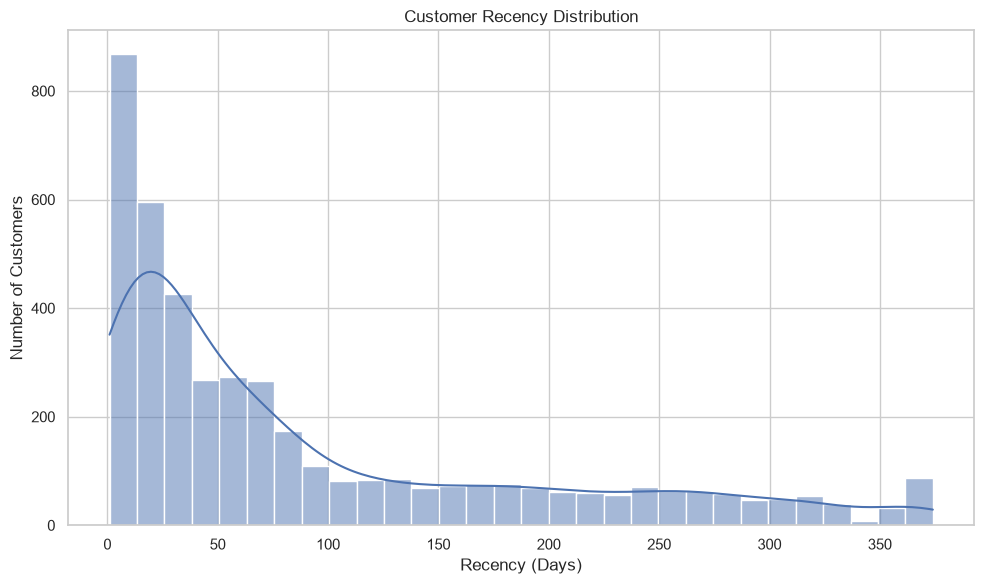

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(rfm['Recency'], bins=30, kde=True)

plt.title('Customer Recency Distribution')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

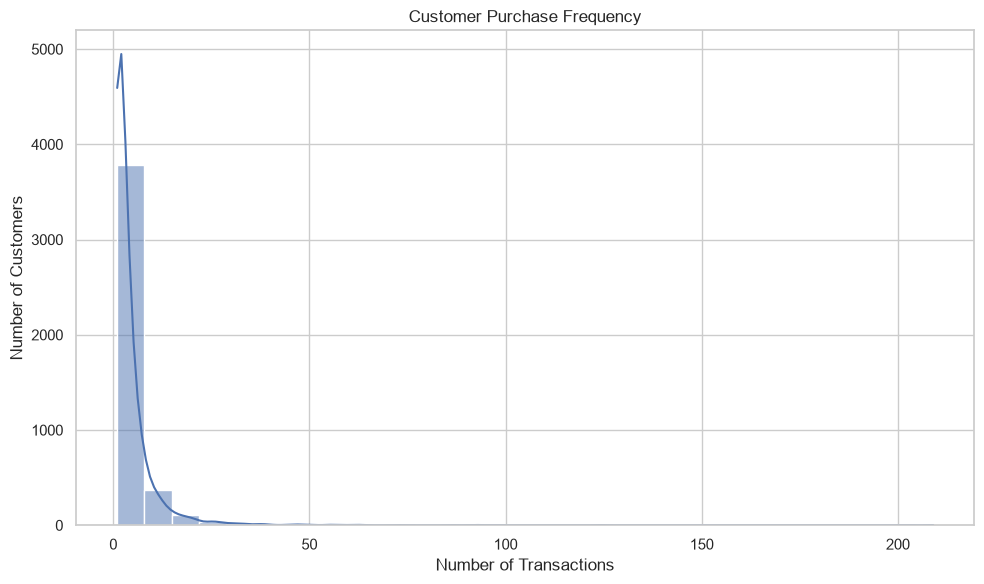

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(rfm['Frequency'], bins=30, kde=True)

plt.title('Customer Purchase Frequency')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation – Purchase Frequency

The frequency distribution shows how often customers purchase.
Customers with higher frequency values demonstrate more repeated
purchasing behaviour and may be more loyal to the business.

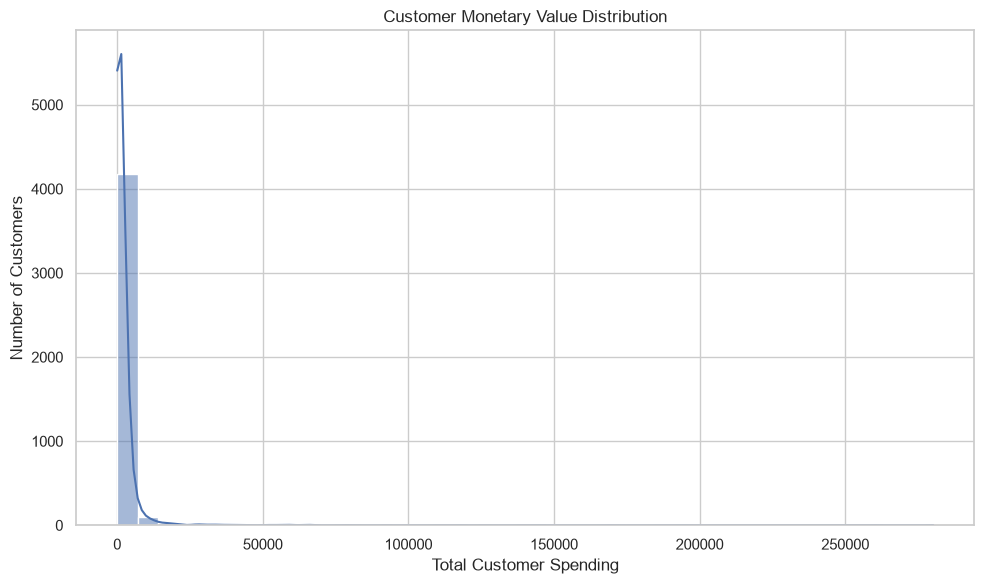

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(rfm['Monetary'], bins=40, kde=True)

plt.title('Customer Monetary Value Distribution')
plt.xlabel('Total Customer Spending')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation – Monetary Value

The monetary distribution shows differences in total customer spending.
Customers with higher monetary values contribute more revenue and may
deserve stronger retention and loyalty strategies.

In [28]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

print("Features selected for clustering:")
print(features.head())

Features selected for clustering:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features = pd.DataFrame(
    scaled_features,
    columns=features.columns,
    index=features.index
)

print("Features standardized successfully!")
print(scaled_features.head())

Features standardized successfully!
             Recency  Frequency  Monetary
CustomerID                               
12346.0     2.334574  -0.425097  8.363010
12347.0    -0.905340   0.354417  0.251699
12348.0    -0.175360  -0.035340 -0.027988
12349.0    -0.735345  -0.425097 -0.032406
12350.0     2.174578  -0.425097 -0.190812


In [30]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    
    inertia.append(kmeans.inertia_)

print("Inertia values:")
print(inertia)

Inertia values:
[9014.566279572977, 5441.3235868296615, 4096.300210662247, 3119.789859800152, 2473.7933635647614, 2023.586627223549, 1717.0110430839188, 1468.787102184298, 1281.0480511013266]


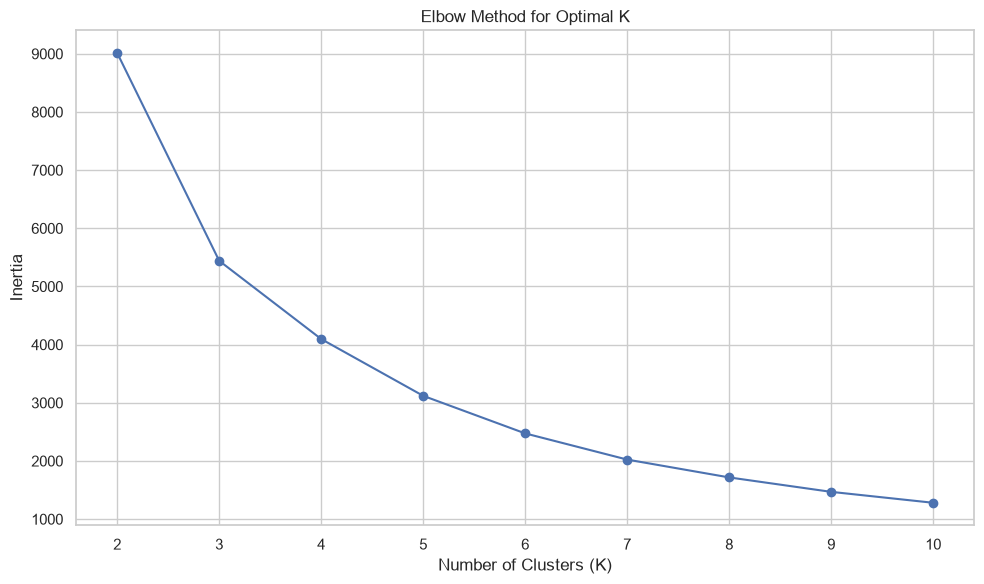

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(K_range)

plt.tight_layout()
plt.show()

In [32]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(scaled_features)

print("K-Means clustering completed successfully!")
print("\nFirst 5 customers:")
print(rfm.head())

K-Means clustering completed successfully!

First 5 customers:
            Recency  Frequency  Monetary  Customer_Lifetime_Value  Cluster
CustomerID                                                                
12346.0         326          1  77183.60                 77183.60        3
12347.0           2          7   4310.00                  4310.00        0
12348.0          75          4   1797.24                  1797.24        0
12349.0          19          1   1757.55                  1757.55        0
12350.0         310          1    334.40                   334.40        1


In [33]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [34]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_Lifetime_Value': 'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary,Customer_Lifetime_Value
Cluster,,,,
0,43.70,3.68,1353.63,1353.63
1,248.08,1.55,478.85,478.85
2,7.38,82.54,127187.96,127187.96
3,15.50,22.33,12690.50,12690.50


In [35]:
segment_names = {
    0: 'Regular / Moderate-Value Customers',
    1: 'At-Risk / Low-Value Customers',
    2: 'High-Value Customers',
    3: 'Loyal / Valuable Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

print(rfm[['Recency', 'Frequency', 'Monetary',
           'Cluster', 'Segment']].head(10))

            Recency  Frequency  Monetary  Cluster  \
CustomerID                                          
12346.0         326          1  77183.60        3   
12347.0           2          7   4310.00        0   
12348.0          75          4   1797.24        0   
12349.0          19          1   1757.55        0   
12350.0         310          1    334.40        1   
12352.0          36          8   2506.04        0   
12353.0         204          1     89.00        1   
12354.0         232          1   1079.40        1   
12355.0         214          1    459.40        1   
12356.0          23          3   2811.43        0   

                                       Segment  
CustomerID                                      
12346.0             Loyal / Valuable Customers  
12347.0     Regular / Moderate-Value Customers  
12348.0     Regular / Moderate-Value Customers  
12349.0     Regular / Moderate-Value Customers  
12350.0          At-Risk / Low-Value Customers  
12352.0     Regular 

In [36]:
final_profile = rfm.groupby(
    ['Cluster', 'Segment']
).agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_Lifetime_Value': 'mean'
}).round(2)

final_profile

,,Recency,Frequency,Monetary,Customer_Lifetime_Value
Cluster,Segment,,,,
0,Regular / Moderate-Value Customers,43.70,3.68,1353.63,1353.63
1,At-Risk / Low-Value Customers,248.08,1.55,478.85,478.85
2,High-Value Customers,7.38,82.54,127187.96,127187.96
3,Loyal / Valuable Customers,15.50,22.33,12690.50,12690.50


In [37]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print("Customers per cluster:")
print(cluster_counts)

Customers per cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


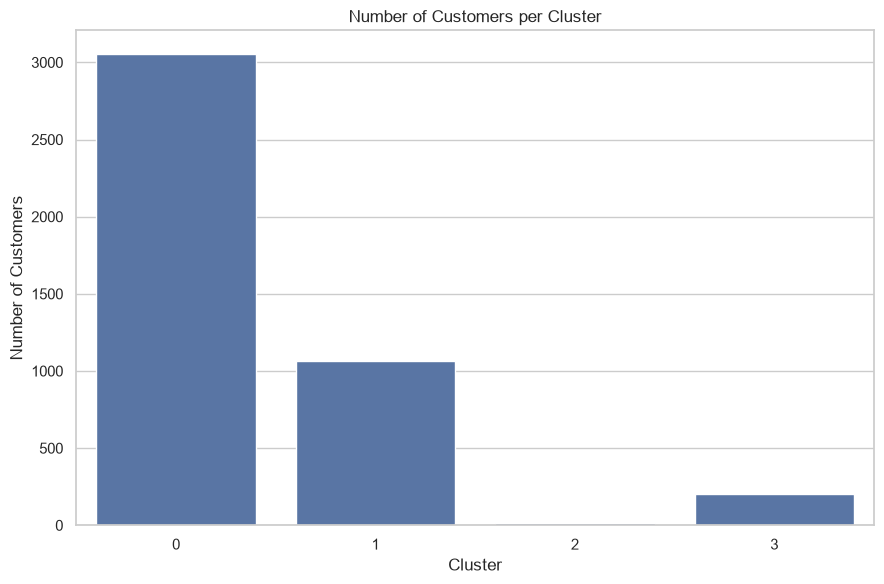

In [38]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

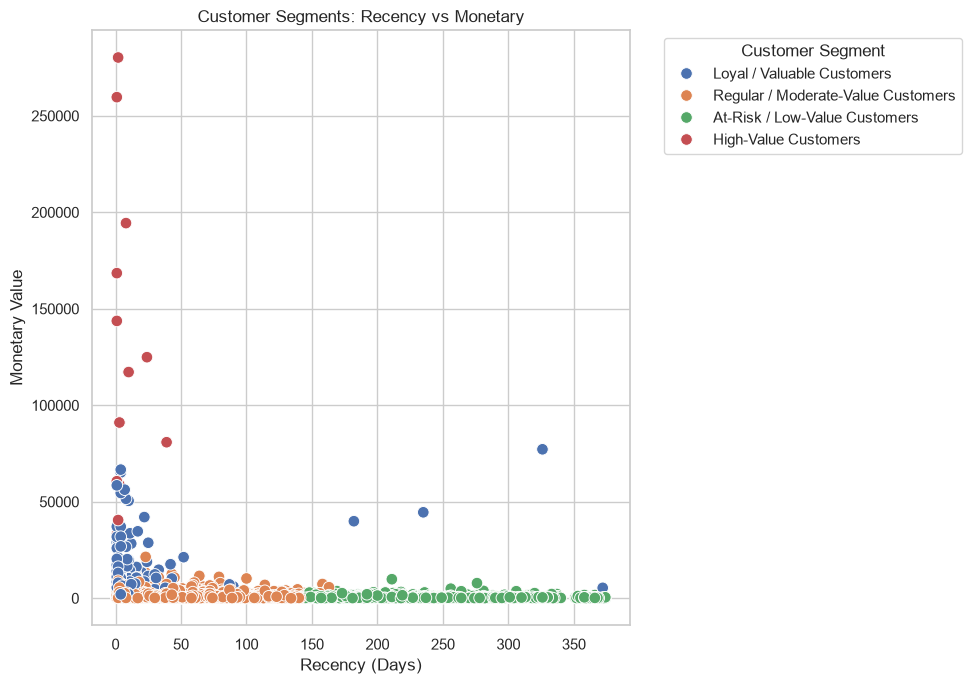

In [39]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    s=70
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

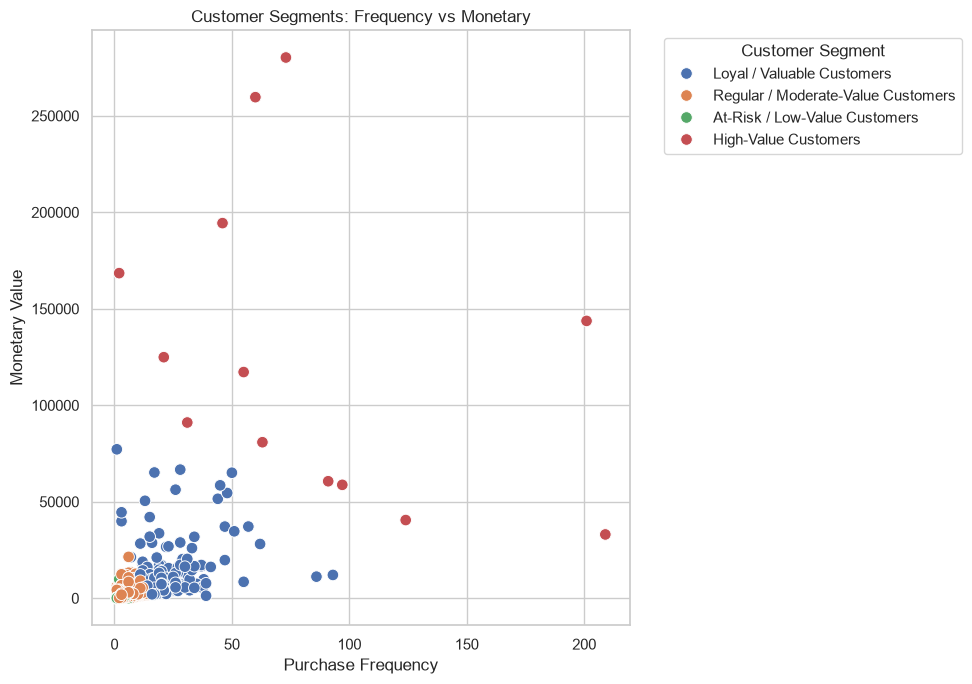

In [40]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    s=70
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

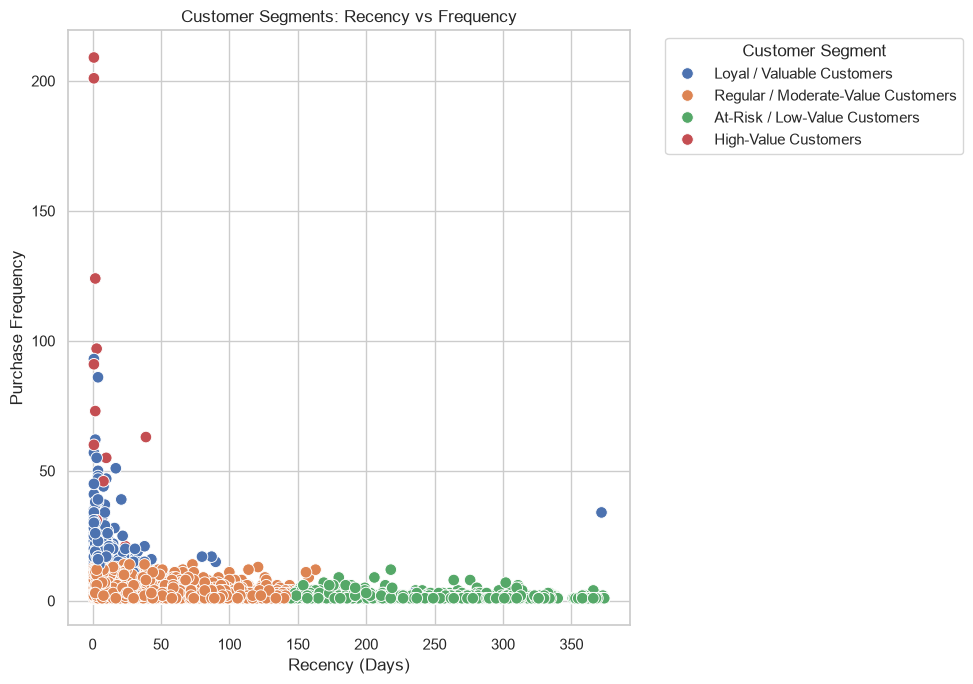

In [41]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Segment',
    s=70
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Purchase Frequency')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Marketing Insights and Recommendations

## 1. High-Value Customers

Cluster 2 represents the highest-value customers. These customers purchase
very recently, purchase frequently, and have very high spending.

### Recommendation:
- Provide VIP loyalty rewards.
- Give exclusive discounts and early access to products.
- Offer personalized recommendations.
- Focus on retaining these customers.

## 2. Loyal / Valuable Customers

Cluster 3 contains customers who purchase recently and relatively
frequently, with strong monetary value.

### Recommendation:
- Provide loyalty points and rewards.
- Encourage repeat purchases.
- Use personalized product recommendations.
- Offer bundle deals and special promotions.

## 3. Regular / Moderate-Value Customers

Cluster 0 contains customers with moderate purchasing activity and
moderate spending.

### Recommendation:
- Encourage more frequent purchases.
- Use loyalty programs and targeted offers.
- Provide product recommendations.
- Promote bundle and cross-selling offers.

## 4. At-Risk / Low-Value Customers

Cluster 1 has the highest recency value, meaning these customers have
not purchased for a long time. They also have relatively low frequency
and monetary value.

### Recommendation:
- Send re-engagement emails.
- Provide personalized discounts.
- Offer limited-time promotions.
- Remind customers about relevant products.

## Overall Recommendation

Different customer segments should receive different marketing
strategies instead of using the same promotion for every customer.
Customer segmentation can help the business improve customer retention,
loyalty, engagement, and marketing effectiveness.

In [43]:
# Key Insights

1. customer purchasing behaviour differs significantly across the four
   identified clusters.

2. Recency helps identify customers who have recently interacted with
   the business.

3. Frequency identifies customers who purchase repeatedly.

4. Monetary value identifies customers who contribute more revenue.

5. Cluster 2 represents the highest-value customer group because it has
   very low recency, very high frequency, and very high monetary value.

6. Cluster 1 represents an at-risk group because customers have not
   purchased recently and have relatively low spending.

7. K-Means clustering successfully groups customers with similar
   purchasing behaviour.

8. The resulting segments can support targeted marketing, customer
   retention, loyalty, and re-engagement strategies.

SyntaxError: invalid syntax (3928474429.py, line 3)

# Key Insights

1. Customer purchasing behaviour differs significantly across the four identified clusters.

2. Recency helps identify customers who have recently interacted with the business.

3. Frequency identifies customers who purchase repeatedly.

4. Monetary value identifies customers who contribute more revenue.

5. Cluster 2 represents the highest-value customer group because it has very low recency, very high frequency, and very high monetary value.

6. Cluster 1 represents an at-risk group because customers have not purchased recently and have relatively low spending.

7. K-Means clustering successfully groups customers with similar purchasing behaviour.

8. The resulting segments can support targeted marketing, customer retention, loyalty, and re-engagement strategies.

In [44]:
rfm.to_csv("RFM_Customer_Segments.csv")

# Conclusion

This project performed customer segmentation using RFM analysis and
K-Means clustering.

The analysis began with data cleaning and preparation, followed by the
calculation of Recency, Frequency, and Monetary metrics for each
customer.

The RFM features were standardized using StandardScaler before applying
K-Means clustering. The Elbow Method was used to determine a suitable
number of clusters, and four customer segments were identified.

The customer segments were visualized using scatter plots and a bar
chart showing the number of customers in each cluster.

The analysis identified high-value, loyal, regular, and at-risk
customers. These segments can help businesses create more personalized
marketing strategies.

Overall, customer segmentation provides a data-driven approach for
improving customer engagement, retention, loyalty, and marketing
decisions.

In [45]:
rfm.to_csv("RFM_Customer_Segments.csv")

print("Final customer segmentation data saved successfully!")

Final customer segmentation data saved successfully!
